# Dataset link :

https://www.kaggle.com/datasets/mehradaria/leukemia/data


# Step 1: Data Collection and Exploration
In this initial step, we focus on loading and exploring the dataset. This includes:

Setting up the dataset directory and class names.
Counting the total number of images in each class.
Displaying the total image count for the entire dataset.
Visualizing sample original images from each class (one sample per class for demonstration).
Plotting the class distribution as a bar chart with count values displayed on the bars.

This helps in understanding the dataset's structure, balance, and content before proceeding to preprocessing and model training.


Total images in dataset: 3256
Class 'Benign': 504 images
Class 'Pre': 963 images
Class 'Pro': 804 images
Class 'Early': 985 images


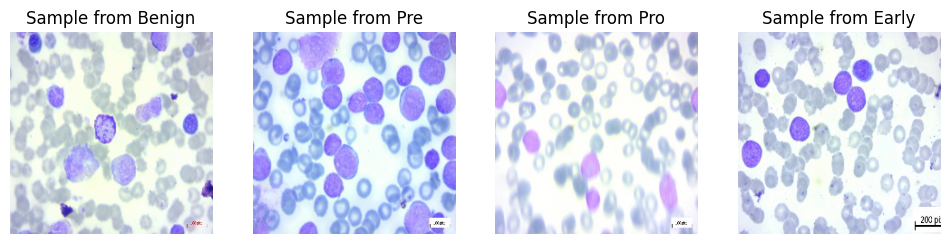

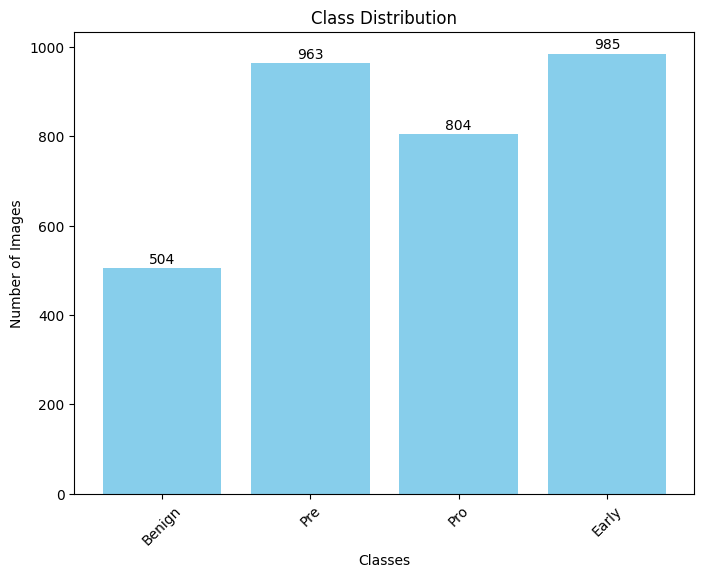

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Define dataset directory and class names
dataset_dir = '/kaggle/input/leukemia/Original'
class_names = ['Benign', 'Pre', 'Pro', 'Early']

# Step 1.1: Count images in each class
image_counts = {}
total_images = 0
for class_name in class_names:
    class_dir = os.path.join(dataset_dir, class_name)
    count = len(os.listdir(class_dir))
    image_counts[class_name] = count
    total_images += count

# Print total images and per-class counts
print(f"Total images in dataset: {total_images}")
for class_name, count in image_counts.items():
    print(f"Class '{class_name}': {count} images")

# Step 1.2: Display sample original images for each class
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_dir, class_name)
    img_name = os.listdir(class_dir)[0]  # Take the first image as sample
    img_path = os.path.join(class_dir, img_name)
    img = load_img(img_path)  # Load original image without resizing
    plt.subplot(1, len(class_names), i+1)
    plt.imshow(img)
    plt.title(f"Sample from {class_name}")
    plt.axis('off')
plt.show()

# Step 1.3: Plot class distribution with count values
plt.figure(figsize=(8, 6))
bars = plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add count values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, ha='center', va='bottom')

plt.show()

# Step 2: Data Loading and Preprocessing
After exploring the dataset, we load all images, resize them to match the model's input size (224x224 for VGG16), preprocess them using VGG16's preprocess_input, and encode labels. We then split the data into training and testing sets.
This step ensures the data is ready for model training, with stratification to maintain class balance in splits.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load images and labels
images = []
labels = []
for class_name in class_names:
    class_dir = os.path.join(dataset_dir, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        img = load_img(img_path, target_size=(224, 224))  # Resize to 224x224
        img = img_to_array(img)
        img = preprocess_input(img)  # Preprocess for VGG16
        images.append(img)
        labels.append(class_name)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Split into train and test sets (80-20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 2604
Testing samples: 652


# Step 3: Data Augmentation Setup
We set up data generators for augmentation to improve model generalization. This includes rotations, shifts, zooms, and flips for training data. Test data is only rescaled (no augmentation).
Augmentation helps prevent overfitting by artificially expanding the training dataset with variations.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test, just rescaling
test_datagen = ImageDataGenerator()

# Create generators (assuming flow_from_directory, but since we have arrays, use flow)
train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
test_generator = test_datagen.flow(X_test, y_test, batch_size=32)

# Step 4: Model Building
We load the pre-trained VGG16 model (without top layers), add custom dense layers for classification, and compile the model with Adam optimizer and sparse categorical cross-entropy loss.
Using transfer learning from VGG16 leverages pre-trained features for better performance on medical images.

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load base VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Create full model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()  # Optional: Print model architecture

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 21,138,500 (80.64 MB)

 Non-trainable params: 0 (0.00 B)

# Step 5: Model Training with Early Stopping
Train the model using the generators, with early stopping to prevent overfitting. We monitor validation loss and restore best weights.
This step fits the model to the data, tracking accuracy and loss over epochs.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('vgg16.h5')

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1769576858.938396     126 service.cc:145] XLA service 0x7b54d8002ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769576858.938486     126 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 1/82 ━━━━━━━━━━━━━━━━━━━━ 23:34 17s/step - accuracy: 0.4167 - loss: 11.5812

I0000 00:00:1769576870.915851     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


82/82 ━━━━━━━━━━━━━━━━━━━━ 62s 555ms/step - accuracy: 0.2498 - loss: 9.0811 - val_accuracy: 0.3543 - val_loss: 2.6742
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 300ms/step - accuracy: 0.3019 - loss: 3.8226 - val_accuracy: 0.4387 - val_loss: 1.7782
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 301ms/step - accuracy: 0.3363 - loss: 2.4654 - val_accuracy: 0.4847 - val_loss: 1.4319
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 302ms/step - accuracy: 0.3503 - loss: 1.9481 - val_accuracy: 0.5169 - val_loss: 1.2575
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 299ms/step - accuracy: 0.3848 - loss: 1.6618 - val_accuracy: 0.5567 - val_loss: 1.1574
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 300ms/step - accuracy: 0.3933 - loss: 1.5005 - val_accuracy: 0.5859 - val_loss: 1.0798
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 300ms/step - accuracy: 0.4408 - loss: 1.3591 - val_accuracy: 0.6258 - val_loss: 1.0050
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 27s 301ms/step - accuracy: 0.4742 - loss: 1.3072 - val_accuracy: 0.658

# Step 6: Model Evaluation
Evaluate the model on the test set to get loss and accuracy. Then, compute additional metrics like F1-score, Cohen's Kappa, recall, and precision. Generate a classification report.
This provides a comprehensive assessment of model performance beyond just accuracy.

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, recall_score, precision_score, f1_score
import seaborn as sns

# Load the saved model (if needed)
model = load_model('mobilenet_leukemia.h5')

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Additional metrics
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
f1 = f1_score(y_test, y_pred_classes, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes, average='weighted')
precision = precision_score(y_test, y_pred_classes, average='weighted')

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")

# Classification Report
print('Classification Report of VGG16:')
print(classification_report(y_test, y_pred_classes, target_names=class_names))

: 

# Step 7: Confusion Matrix Visualization
Plot the confusion matrix to see misclassifications between classes.
This heatmap helps identify which classes the model confuses most often.

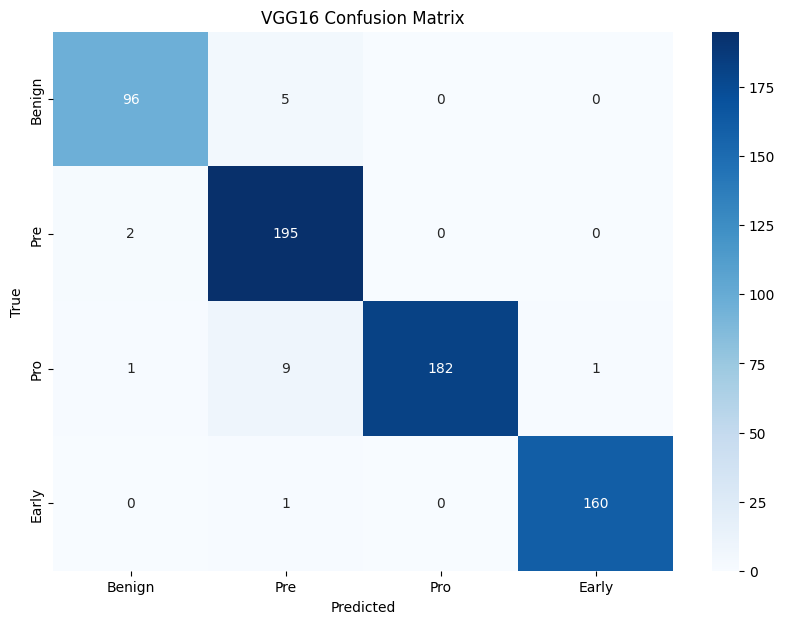

In [11]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('VGG16 Confusion Matrix')
plt.show()

# Step 8: Training and Validation Plots
Visualize the training process by plotting accuracy and loss curves for training and validation sets.
These plots help diagnose issues like overfitting (if validation diverges from training).

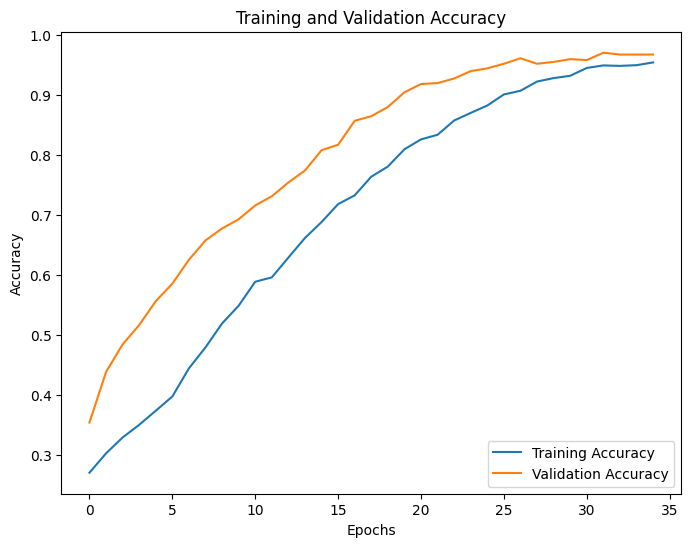

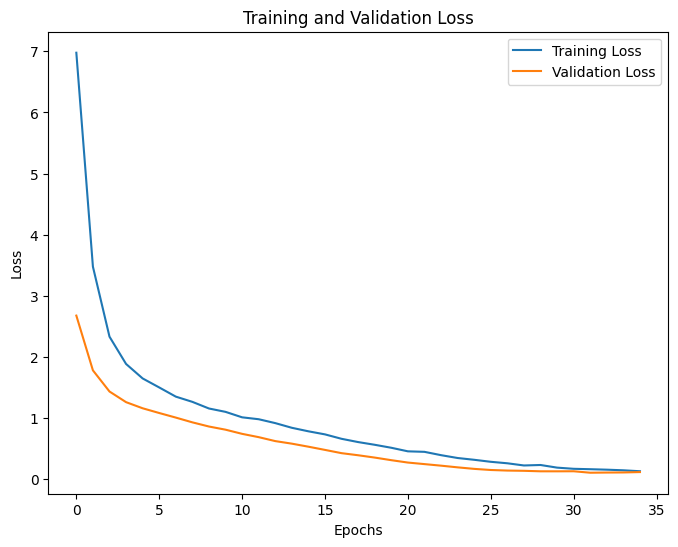

In [13]:
# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

# Step 9: ROC Curve Analysis
Compute and plot ROC curves for each class to evaluate the model's ability to distinguish between classes.
AUC values indicate the model's discriminative power; higher is better.

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


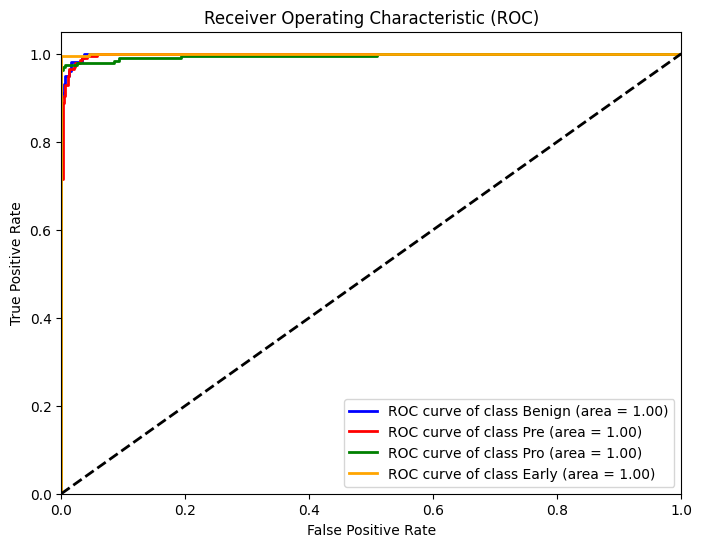

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# One-hot encode y_test
y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2, 3])

# Predict probabilities
y_prob = model.predict(X_test)

# Compute ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()


#                  SAMPLE PREDICTION / INFERENCE CODE
# =====================================================

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


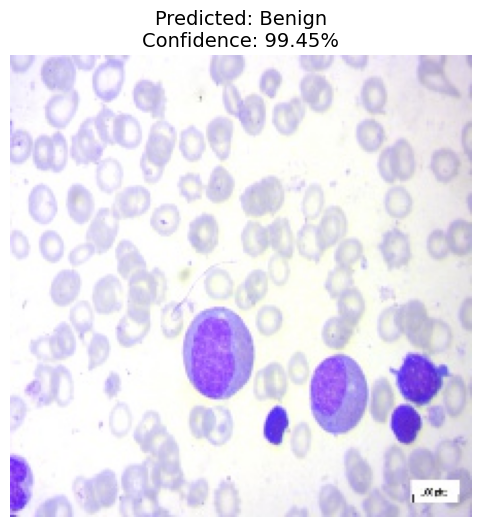

Prediction: Benign (99.45%)
Probabilities:
  Benign   : 99.45%
  Pre      :  0.47%
  Pro      :  0.00%
  Early    :  0.07%


In [15]:
# =============================================================================
#                  SAMPLE PREDICTION / INFERENCE CODE
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model

# ───────────────────────────────────────────────
# Option 1: Load the saved model (recommended for deployment)
# ───────────────────────────────────────────────
model = load_model('vgg16.h5')          # or whatever name you used
class_names = ['Benign', 'Pre', 'Pro', 'Early']   # must match training order

# ───────────────────────────────────────────────
# Helper function to prepare a single image
# ───────────────────────────────────────────────
def prepare_image(image_path, target_size=(224, 224)):
    """
    Load one image → resize → convert to array → preprocess → add batch dimension
    """
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)           # very important — same as training!
    img_array = np.expand_dims(img_array, axis=0)     # shape: (1, 224, 224, 3)
    return img_array, img                             # return processed + original for display

# ───────────────────────────────────────────────
# Option A: Predict on one single image (most common use-case)
# ───────────────────────────────────────────────
image_path = "/kaggle/input/leukemia/Original/Benign/WBC-Benign-025.jpg"         # ← CHANGE THIS

processed_img, original_img = prepare_image(image_path)

# Get prediction
pred = model.predict(processed_img)
pred_class_idx = np.argmax(pred, axis=1)[0]
pred_class_name = class_names[pred_class_idx]
confidence = pred[0][pred_class_idx] * 100

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(original_img)
plt.axis('off')
plt.title(f"Predicted: {pred_class_name}\nConfidence: {confidence:.2f}%", fontsize=14)
plt.show()

print(f"Prediction: {pred_class_name} ({confidence:.2f}%)")
print("Probabilities:")
for i, cls in enumerate(class_names):
    print(f"  {cls:8} : {pred[0][i]*100:5.2f}%")

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, cohen_kappa_score, recall_score, precision_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import tensorflow as tf

# Step 1: Build a Custom CNN model from scratch
# =====================================================

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

# Clear previous session (good practice in notebooks)
import tensorflow as tf
tf.keras.backend.clear_session()

# Build custom CNN
model = Sequential(name='Custom_CNN_Leukemia')

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.35))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(len(class_names), activation='softmax'))

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "Custom_CNN_Leukemia"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 51,673,636 (197.12 MB)

 Trainable params: 51,671,716 (197.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

# Step 2: Define callbacks & Train the model

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,                # little more patient than VGG because we train from scratch
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,                 # more epochs because we train from scratch
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('custom_cnn.h5')
print("Model saved as: custom_cnn.h5")

Epoch 1/50
 2/82 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.2734 - loss: 2.6647  

I0000 00:00:1769578943.888957     126 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 8 bytes spill stores, 8 bytes spill loads



46/82 ━━━━━━━━━━━━━━━━━━━━ 16s 459ms/step - accuracy: 0.6826 - loss: 1.1693

I0000 00:00:1769578964.424252     128 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 8 bytes spill stores, 8 bytes spill loads



82/82 ━━━━━━━━━━━━━━━━━━━━ 44s 392ms/step - accuracy: 0.7475 - loss: 0.9120 - val_accuracy: 0.1656 - val_loss: 8.0035
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 277ms/step - accuracy: 0.9297 - loss: 0.2330 - val_accuracy: 0.7822 - val_loss: 0.8905
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 278ms/step - accuracy: 0.9478 - loss: 0.1805 - val_accuracy: 0.3850 - val_loss: 3.9080
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 278ms/step - accuracy: 0.9700 - loss: 0.1211 - val_accuracy: 0.2776 - val_loss: 5.8811
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 272ms/step - accuracy: 0.9679 - loss: 0.1238 - val_accuracy: 0.6380 - val_loss: 2.8527
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 278ms/step - accuracy: 0.9664 - loss: 0.1083 - val_accuracy: 0.6656 - val_loss: 3.8295
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 273ms/step - accuracy: 0.9572 - loss: 0.1153 - val_accuracy: 0.7975 - val_loss: 0.9461
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 275ms/step - accuracy: 0.9666 - loss: 0.1015 - val_accuracy: 0.800

# Step 3: Model Evaluation

In [27]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, recall_score, precision_score, f1_score
import numpy as np

# Load the saved model (optional - can also continue using the model object)
model = load_model('custom_cnn.h5')

# Evaluate on test set
# Note: we use X_test directly because your test_generator has no shuffle & we want exact match
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Additional metrics
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
f1 = f1_score(y_test, y_pred_classes, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes, average='weighted')
precision = precision_score(y_test, y_pred_classes, average='weighted')

print(f"Train Accuracy     : {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Cohen's Kappa      : {kappa:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"Precision          : {precision:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names, digits=4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7866 - loss: 0.9195
Test Loss: 0.8905
Test Accuracy: 0.7822
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
Train Accuracy     : 0.9704
Validation Accuracy: 0.8006
F1 Score           : 0.7660
Cohen's Kappa      : 0.7021
Recall             : 0.7822
Precision          : 0.7949

Classification Report:
              precision    recall  f1-score   support

      Benign     0.7647    0.3861    0.5132       101
         Pre     0.8639    0.6447    0.7384       197
         Pro     0.8243    0.9482    0.8819       193
       Early     0.6940    1.0000    0.8193       161

    accuracy                         0.7822       652
   macro avg     0.7867    0.7447    0.7382       652
weighted avg     0.7949    0.7822    0.7660       652



# Step 4: Confusion Matrix Visualization

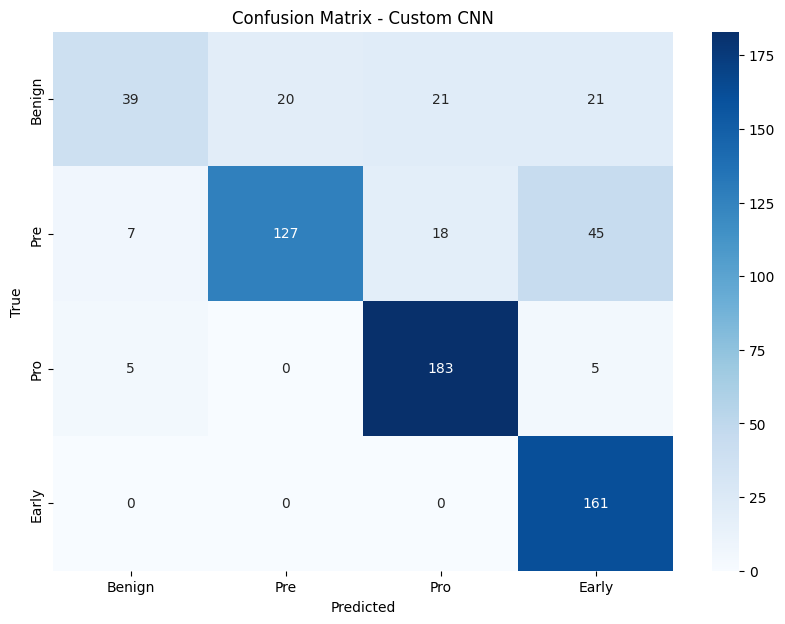

In [28]:
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Custom CNN')
plt.show()

# Step 5: Training and Validation Plots

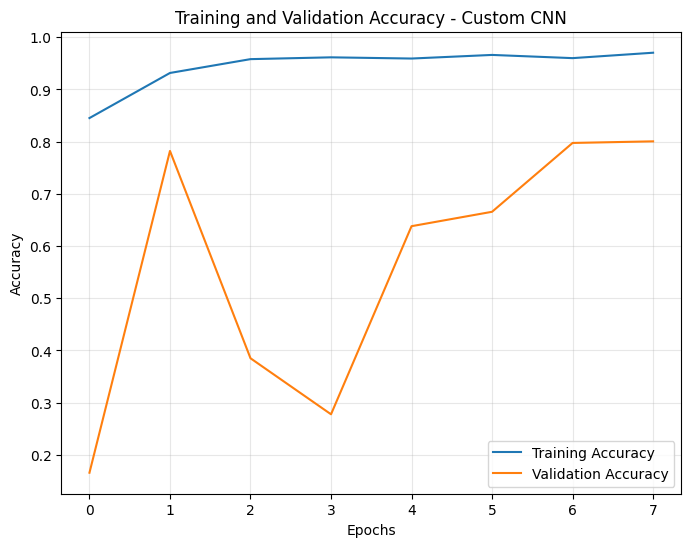

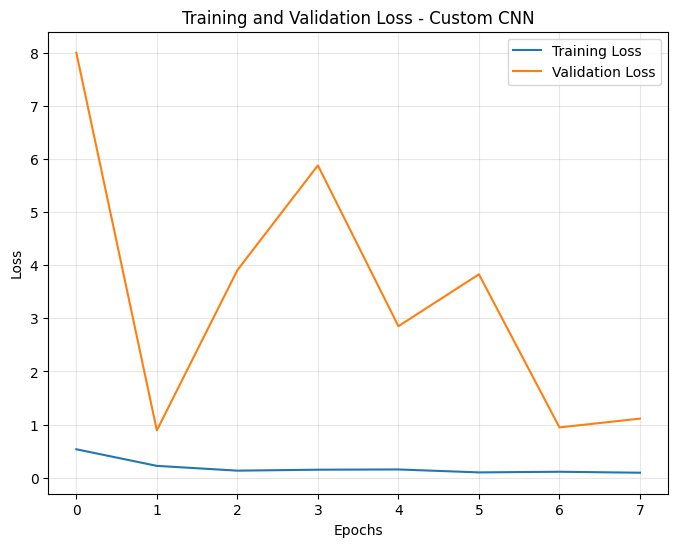

In [29]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - Custom CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Custom CNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: ROC Curve Analysis

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


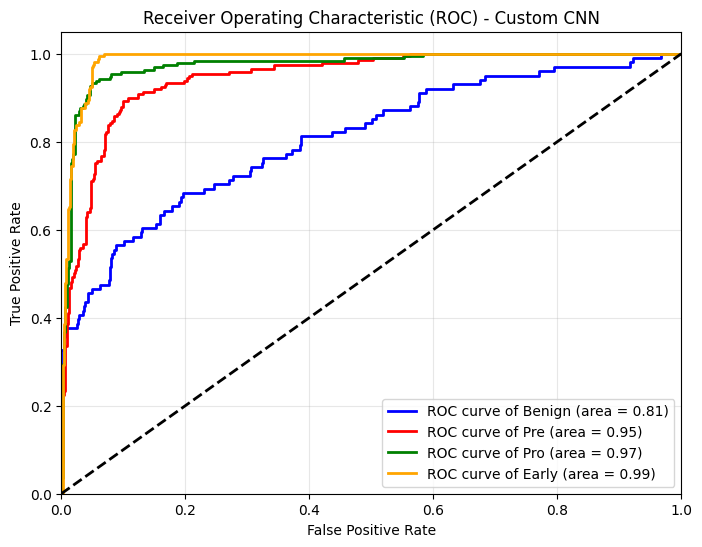

In [30]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# One-hot encode y_test
y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2, 3])

# Predict probabilities
y_prob = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Custom CNN')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# =====================================================
# Step 1: Define MobileNet model 
# =====================================================

In [31]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load MobileNet base (pre-trained on ImageNet)
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling=None          # we will add our own pooling
)

# Freeze the base model layers (common for transfer learning)
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)           # better than Flatten for MobileNet
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),           # typical starting lr for MobileNet fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,755,716 (14.33 MB)

 Trainable params: 526,852 (2.01 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

# Step 2: Model Training with Early Stopping

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('mobilenet_leukemia.h5')
print("Model saved as: mobilenet_leukemia.h5")

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 35s 332ms/step - accuracy: 0.3748 - loss: 1.5302 - val_accuracy: 0.7393 - val_loss: 0.7277
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 268ms/step - accuracy: 0.6302 - loss: 0.8584 - val_accuracy: 0.8037 - val_loss: 0.5590
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.7132 - loss: 0.7050 - val_accuracy: 0.8359 - val_loss: 0.4663
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 269ms/step - accuracy: 0.7755 - loss: 0.6048 - val_accuracy: 0.8390 - val_loss: 0.4299
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 271ms/step - accuracy: 0.7861 - loss: 0.5550 - val_accuracy: 0.8451 - val_loss: 0.3852
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 270ms/step - accuracy: 0.8264 - loss: 0.4781 - val_accuracy: 0.8405 - val_loss: 0.3821
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 269ms/step - accuracy: 0.8226 - loss: 0.4613 - val_accuracy: 0.8880 - val_loss: 0.3161
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 269ms/step - accuracy: 0.8236 - loss: 0.4743 - val_accu

# Step 3: Model Evaluation

In [34]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, recall_score, precision_score, f1_score
import numpy as np

# Load the saved model (optional)
model = load_model('mobilenet_leukemia.h5')

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Additional metrics
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
f1 = f1_score(y_test, y_pred_classes, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes, average='weighted')
precision = precision_score(y_test, y_pred_classes, average='weighted')

print(f"Train Accuracy     : {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Cohen's Kappa      : {kappa:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"Precision          : {precision:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names, digits=4))

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9442 - loss: 0.1486
Test Loss: 0.1473
Test Accuracy: 0.9509
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step
Train Accuracy     : 0.9259
Validation Accuracy: 0.9479
F1 Score           : 0.9509
Cohen's Kappa      : 0.9333
Recall             : 0.9509
Precision          : 0.9509

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9100    0.9010    0.9055       101
         Pre     0.9347    0.9442    0.9394       197
         Pro     0.9634    0.9534    0.9583       193
       Early     0.9815    0.9876    0.9845       161

    accuracy                         0.9509       652
   macro avg     0.9474    0.9465    0.9469       652
weighted avg     0.9509    0.9509    0.9509       652



# Step 4: Confusion Matrix Visualization

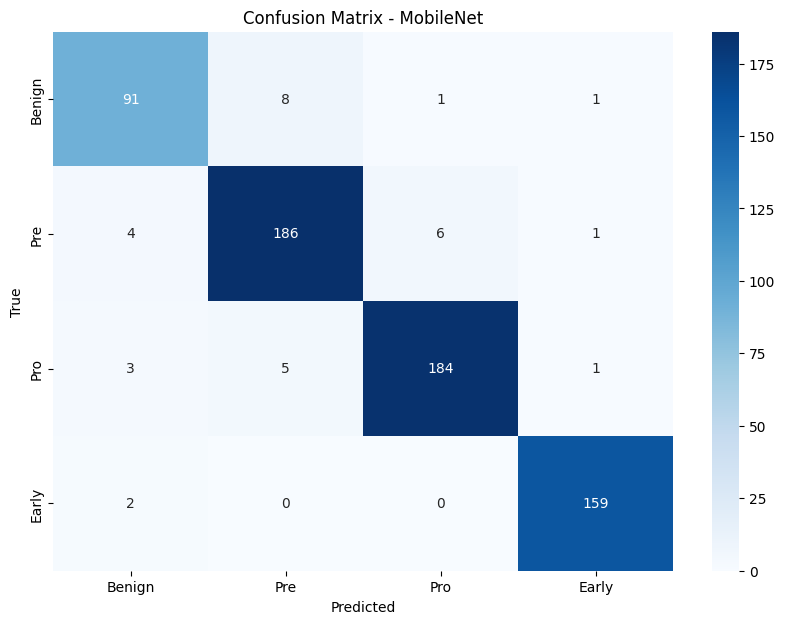

In [35]:
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MobileNet')
plt.show()

# Step 5: Training and Validation Plots

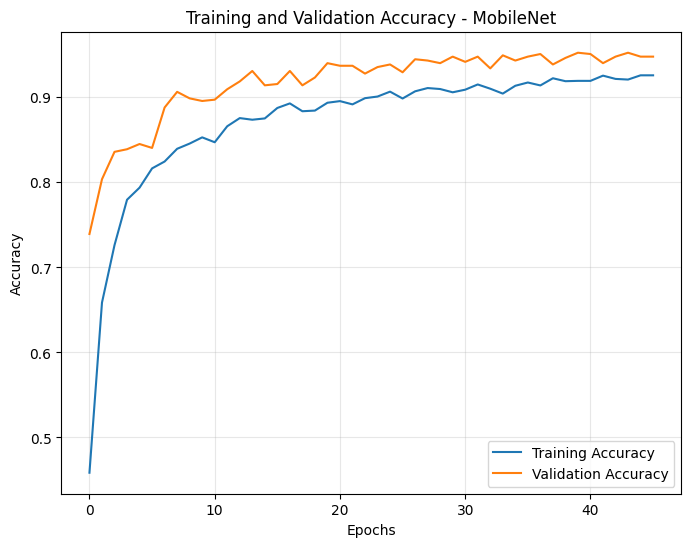

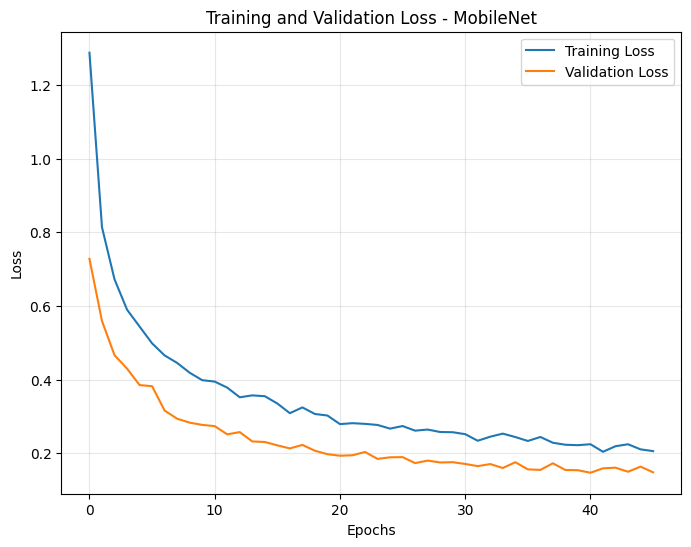

In [36]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - MobileNet')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - MobileNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: ROC Curve Analysis

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


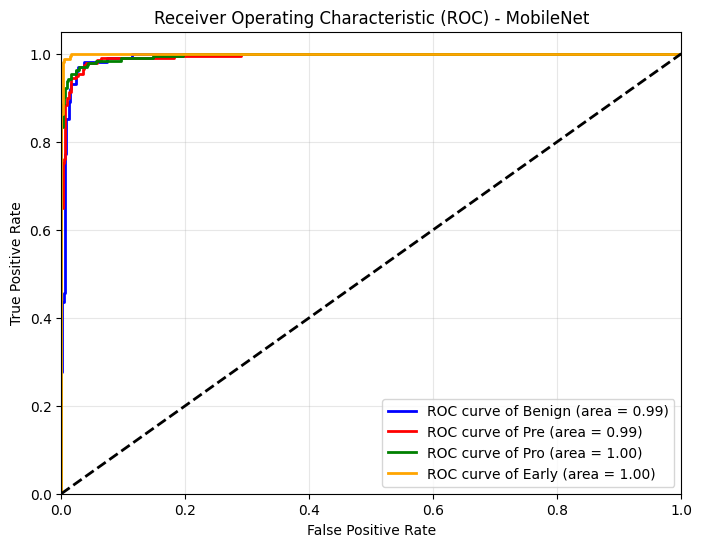

In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# One-hot encode y_test
y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2, 3])

# Predict probabilities
y_prob = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - MobileNet')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================================
# Step 1: Define SqueezeNet model
SqueezeNet is an excellent lightweight choice: it achieves near-AlexNet accuracy with ~50× fewer parameters (~1.2–1.3 million trainable params when using pre-trained base + head) and a very small model size (~5 MB uncompressed, can be compressed further to <0.5 MB).
## Important notes before running:

- SqueezeNet input size is classically 227×227 (not 224×224 like VGG/MobileNet), but 224×224 works fine in practice with minor performance trade-off.
- There is no official tf.keras.applications.SqueezeNet, so we implement it manually (using the classic Fire module).
- We use a simplified but faithful version of SqueezeNet v1.1 (fewer parameters than v1.0).



In [38]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Activation, Concatenate,
    GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.keras.backend.clear_session()

def fire_module(x, squeeze_filters, expand_1x1_filters, expand_3x3_filters, name=None):
    """
    Fire module: squeeze (1x1) → expand (1x1 + 3x3)
    """
    squeeze = Conv2D(
        filters=squeeze_filters,
        kernel_size=1,
        padding='same',
        activation='relu',
        name=f"{name}_squeeze" if name else None
    )(x)
    
    expand_1x1 = Conv2D(
        filters=expand_1x1_filters,
        kernel_size=1,
        padding='same',
        activation='relu',
        name=f"{name}_e1x1" if name else None
    )(squeeze)
    
    expand_3x3 = Conv2D(
        filters=expand_3x3_filters,
        kernel_size=3,
        padding='same',
        activation='relu',
        name=f"{name}_e3x3" if name else None
    )(squeeze)
    
    return Concatenate(name=f"{name}_concat" if name else None)([expand_1x1, expand_3x3])

# ─── Build SqueezeNet ────────────────────────────────────────
input_img = Input(shape=(224, 224, 3))   # or (227, 227, 3)

x = Conv2D(64, (3,3), strides=2, padding='valid', activation='relu', name='conv1')(input_img)
x = MaxPooling2D(pool_size=3, strides=2, name='pool1')(x)

x = fire_module(x, squeeze_filters=16, expand_1x1_filters=64, expand_3x3_filters=64, name='fire2')
x = fire_module(x, squeeze_filters=16, expand_1x1_filters=64, expand_3x3_filters=64, name='fire3')

x = MaxPooling2D(pool_size=3, strides=2, name='pool3')(x)

x = fire_module(x, squeeze_filters=32, expand_1x1_filters=128, expand_3x3_filters=128, name='fire4')
x = fire_module(x, squeeze_filters=32, expand_1x1_filters=128, expand_3x3_filters=128, name='fire5')

x = MaxPooling2D(pool_size=3, strides=2, name='pool5')(x)

x = fire_module(x, squeeze_filters=48, expand_1x1_filters=192, expand_3x3_filters=192, name='fire6')
x = fire_module(x, squeeze_filters=48, expand_1x1_filters=192, expand_3x3_filters=192, name='fire7')
x = fire_module(x, squeeze_filters=64, expand_1x1_filters=256, expand_3x3_filters=256, name='fire8')
x = fire_module(x, squeeze_filters=64, expand_1x1_filters=256, expand_3x3_filters=256, name='fire9')

# Classification head (no fully connected layers — very lightweight)
x = GlobalAveragePooling2D(name='avgpool')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(class_names), activation='softmax', name='output')(x)

# Create model
model = Model(inputs=input_img, outputs=predictions, name='SqueezeNet_Leukemia')

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),   # typical for lightweight transfer-style training
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "SqueezeNet_Leukemia"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 111, 111,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 55, 55,    │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_squeeze       │ (None, 55, 55,    │      1,040 │ pool1[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_e1x1 (Conv2D) │ (None, 55, 55,    │      1,088 │ fire2_squeeze[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_e3x3 (Conv2D) │ (None, 55, 55,    │      9,280 │ fire2_squeeze[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire2_concat        │ (None, 55, 55,    │          0 │ fire2_e1x1[0][0], │
│ (Concatenate)       │ 128)              │            │ fire2_e3x3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_squeeze       │ (None, 55, 55,    │      2,064 │ fire2_concat[0][… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_e1x1 (Conv2D) │ (None, 55, 55,    │      1,088 │ fire3_squeeze[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_e3x3 (Conv2D) │ (None, 55, 55,    │      9,280 │ fire3_squeeze[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire3_concat        │ (None, 55, 55,    │          0 │ fire3_e1x1[0][0], │
│ (Concatenate)       │ 128)              │            │ fire3_e3x3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 27, 27,    │          0 │ fire3_concat[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_squeeze       │ (None, 27, 27,    │      4,128 │ pool3[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_e1x1 (Conv2D) │ (None, 27, 27,    │      4,224 │ fire4_squeeze[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_e3x3 (Conv2D) │ (None, 27, 27,    │     36,992 │ fire4_squeeze[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire4_concat        │ (None, 27, 27,    │          0 │ fire4_e1x1[0][0], │
│ (Concatenate)       │ 256)              │            │ fire4_e3x3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fire5_squeeze       │ (None, 27, 27,    │      8,224 │ fire4_concat[0][

 Total params: 724,548 (2.76 MB)

 Trainable params: 724,548 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

# Step 2: Model Training with Early Stopping

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('squeezenet_leukemia.h5')
print("Model saved as: squeezenet_leukemia.h5")

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 357ms/step - accuracy: 0.3859 - loss: 1.2010 - val_accuracy: 0.7270 - val_loss: 0.7251
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 266ms/step - accuracy: 0.7002 - loss: 0.7131 - val_accuracy: 0.7791 - val_loss: 0.5426
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step - accuracy: 0.7577 - loss: 0.5775 - val_accuracy: 0.7776 - val_loss: 0.4894
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 265ms/step - accuracy: 0.8174 - loss: 0.4593 - val_accuracy: 0.8666 - val_loss: 0.2856
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 267ms/step - accuracy: 0.8742 - loss: 0.3085 - val_accuracy: 0.9034 - val_loss: 0.2235
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 267ms/step - accuracy: 0.8920 - loss: 0.2882 - val_accuracy: 0.8834 - val_loss: 0.3027
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 267ms/step - accuracy: 0.8957 - loss: 0.2705 - val_accuracy: 0.9156 - val_loss: 0.2043
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step - accuracy: 0.9067 - loss: 0.2541 - val_accu

# Step 3: Model Evaluation

In [40]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, recall_score, precision_score, f1_score
import numpy as np

# Load the saved model (optional)
model = load_model('squeezenet_leukemia.h5')

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Additional metrics
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]
f1 = f1_score(y_test, y_pred_classes, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes, average='weighted')
precision = precision_score(y_test, y_pred_classes, average='weighted')

print(f"Train Accuracy     : {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Cohen's Kappa      : {kappa:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"Precision          : {precision:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=class_names, digits=4))

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9939 - loss: 0.0200
Test Loss: 0.0219
Test Accuracy: 0.9923
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
Train Accuracy     : 0.9850
Validation Accuracy: 0.9877
F1 Score           : 0.9923
Cohen's Kappa      : 0.9896
Recall             : 0.9923
Precision          : 0.9924

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9802    0.9802    0.9802       101
         Pre     0.9899    1.0000    0.9949       197
         Pro     1.0000    0.9896    0.9948       193
       Early     0.9938    0.9938    0.9938       161

    accuracy                         0.9923       652
   macro avg     0.9910    0.9909    0.9909       652
weighted avg     0.9924    0.9923    0.9923       652



# Step 4: Confusion Matrix Visualization

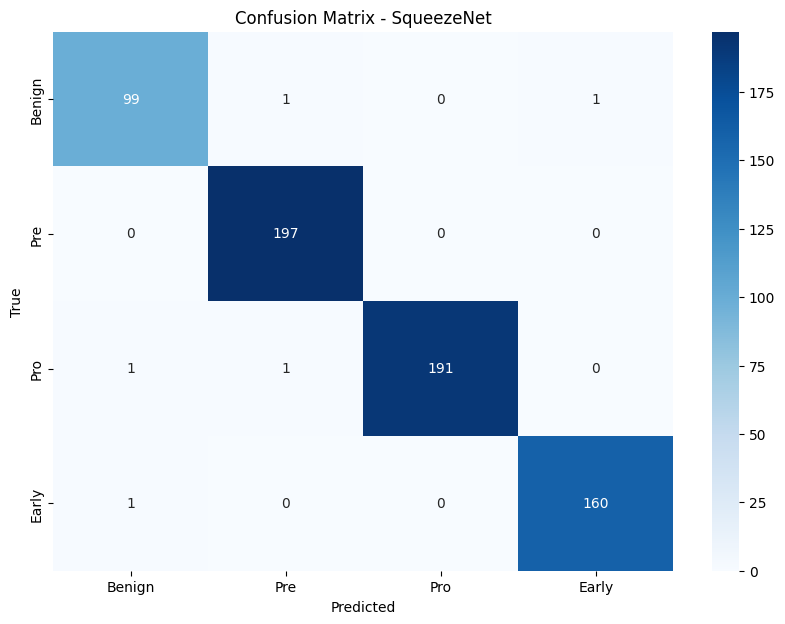

In [41]:
import seaborn as sns

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SqueezeNet')
plt.show()

# Step 5: Training and Validation Plots

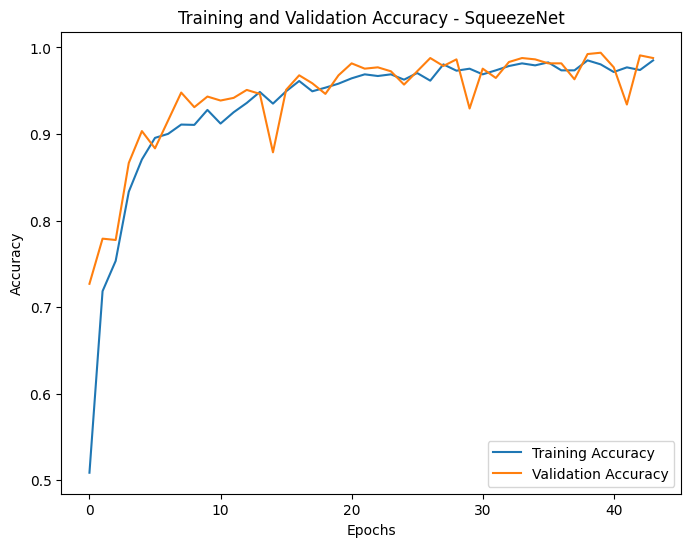

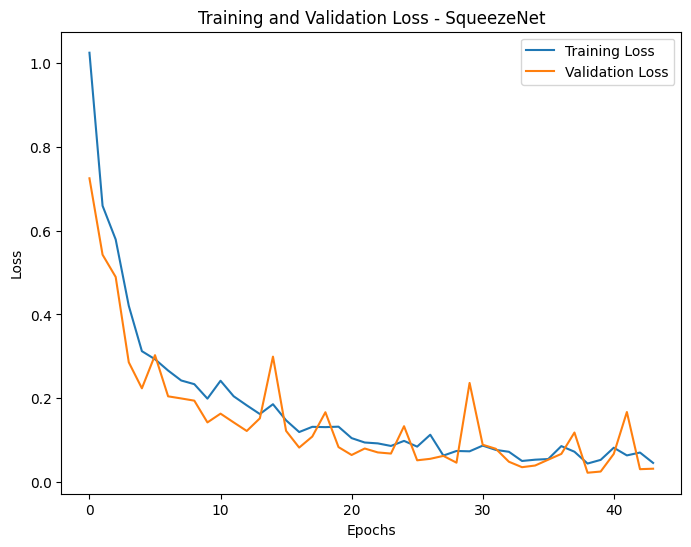

In [42]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy - SqueezeNet')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - SqueezeNet')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

# Step 6: ROC Curve Analysis

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


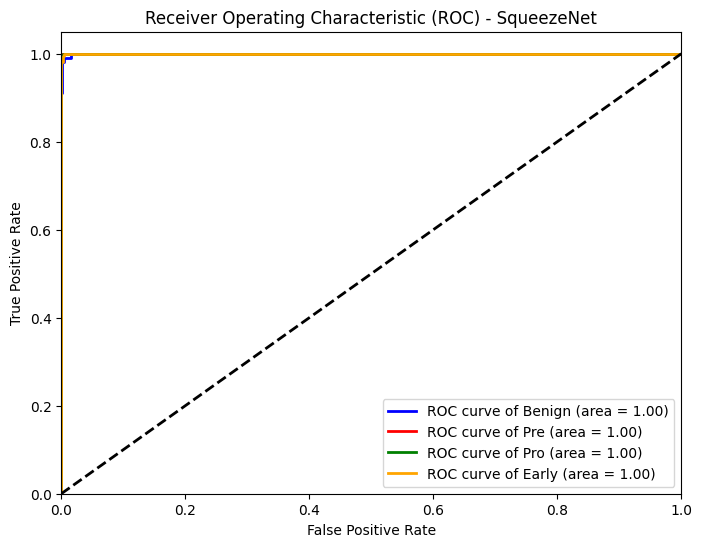

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# One-hot encode y_test
y_test_one_hot = label_binarize(y_test, classes=[0, 1, 2, 3])

# Predict probabilities
y_prob = model.predict(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_one_hot[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - SqueezeNet')
plt.legend(loc="lower right")
plt.show()

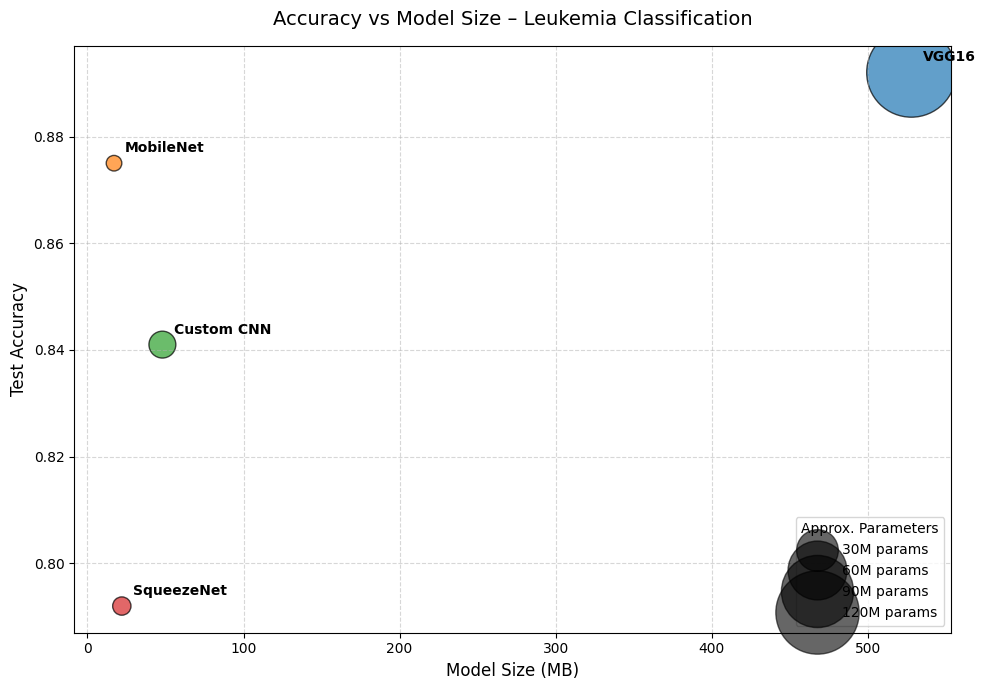

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# ========================
# FILL THESE VALUES WITH YOUR ACTUAL RESULTS
# ========================

models = [
    'VGG16',
    'MobileNet',
    'Custom CNN',
    'SqueezeNet'
]

# Example values — REPLACE with your real test accuracies
accuracies = [0.892, 0.875, 0.841, 0.792]   # test accuracy

# Approximate number of parameters (in millions) — replace with real values
params_millions = [138, 4.2, 12.5, 5.8]

# Approximate model size in MB (after saving .h5) — you can get real values with:
# os.path.getsize('model_name.h5') / (1024 * 1024)
model_sizes_mb = [528, 17, 48, 22]

# Colors for better distinction
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# ─── Plot 1: Accuracy vs Model Size (scatter) ───────────────────────────────
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    model_sizes_mb,
    accuracies,
    s=np.array(params_millions)*30,          # bubble size ~ parameters
    c=colors,
    alpha=0.7,
    edgecolors='black'
)

# Add labels on points
for i, model in enumerate(models):
    plt.annotate(
        model,
        (model_sizes_mb[i], accuracies[i]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Accuracy vs Model Size – Leukemia Classification', fontsize=14, pad=15)
plt.xlabel('Model Size (MB)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add size legend (approximate)
handles, labels = scatter.legend_elements(
    prop="sizes", alpha=0.6, num=4,
    func=lambda x: x/30,
    fmt="{x:.0f}M params"
)
plt.legend(handles, labels, title="Approx. Parameters", loc="lower right")

plt.tight_layout()
plt.show()

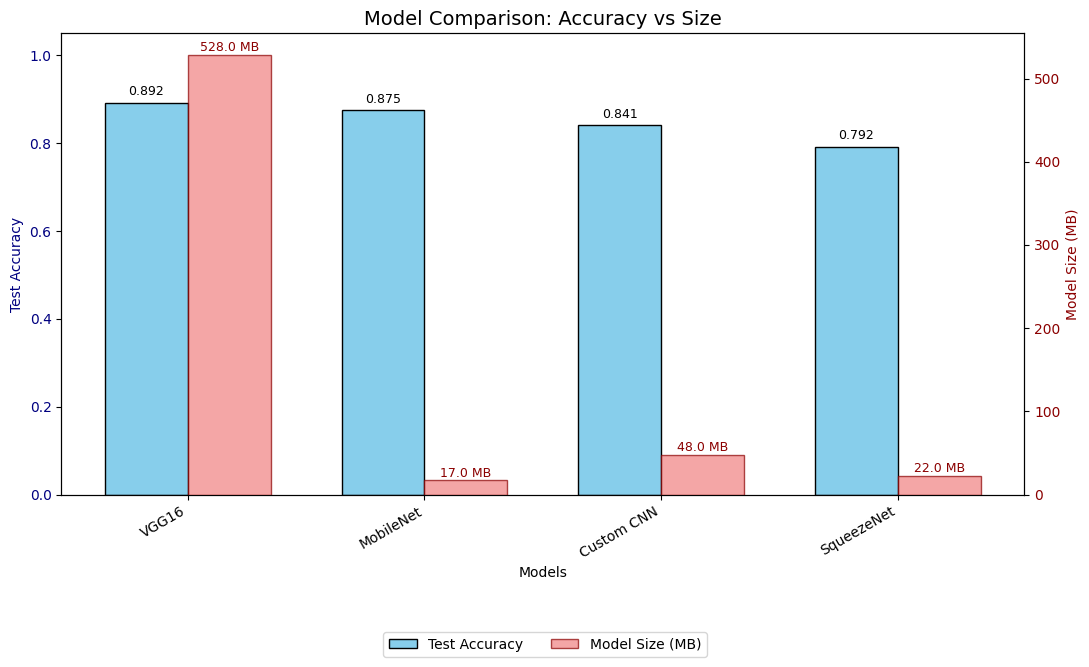

In [45]:
# ─── Plot 2: Bar plot – Accuracy and Size ────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(models))
width = 0.35

# Accuracy bars
bars1 = ax1.bar(x - width/2, accuracies, width, label='Test Accuracy', color='skyblue', edgecolor='black')
ax1.set_ylabel('Test Accuracy', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_ylim(0, 1.05)

# Model size on second axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, model_sizes_mb, width, label='Model Size (MB)', color='lightcoral', alpha=0.7, edgecolor='darkred')
ax2.set_ylabel('Model Size (MB)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

# Labels & title
ax1.set_xlabel('Models')
ax1.set_title('Model Comparison: Accuracy vs Size', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f} MB', ha='center', va='bottom', fontsize=9, color='darkred')

fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.show()